In [27]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
from imblearn.combine import SMOTEENN
from scipy.stats import entropy
from sklearn.metrics import classification_report
# Load data
df = pd.read_csv('student_performance_dataset.csv')

# Categorization
def categorize_performance(score):
    if score < 55: return 0
    elif score < 73: return 1
    else: return 2

df['Performance_Class'] = df['Final_Exam_Score'].apply(categorize_performance)

# Encoding
le = LabelEncoder()
cat_cols = ['Gender', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(['Student_ID', 'Final_Exam_Score', 'Pass_Fail', 'Performance_Class'], axis=1)
y = df['Performance_Class']

# Feature Engineering: Interactions
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)
feat_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feat_names)

# Symmetric Uncertainty Calculation
def calculate_su(x, y):
    def get_entropy(c):
        counts = np.unique(c, return_counts=True)[1]
        return entropy(counts)
    
    # IG(X,Y) = H(X) + H(Y) - H(X,Y)
    # This is equivalent to mutual_info_classif for discrete/continuous mix
    mi = mutual_info_classif(x.reshape(-1, 1), y, random_state=42)[0]
    hx = get_entropy(x)
    hy = get_entropy(y)
    if hx + hy == 0: return 0
    return 2 * mi / (hx + hy)

su_scores = []
for col in X_poly_df.columns:
    su_scores.append(calculate_su(X_poly_df[col].values, y.values))

su_series = pd.Series(su_scores, index=X_poly_df.columns).sort_values(ascending=False)
# Keep top features
selected_feats = su_series.head(15).index.tolist()
X_selected = X_poly_df[selected_feats]

# Preprocessing: Z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# SMOTE-ENN for cleaner boundaries
sme = SMOTEENN(random_state=42)
X_res, y_res = sme.fit_resample(X_scaled, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Hybrid Model: Stacking RF and XGB
# Hyperparameters tuned for high accuracy
rf = RandomForestClassifier(n_estimators=500, max_depth=25, min_samples_split=2, random_state=42)
xgb = XGBClassifier(n_estimators=800, learning_rate=0.03, max_depth=10, subsample=0.8, colsample_bytree=0.8, random_state=42)

# Decision-level fusion (Stacking)
clf = StackingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    final_estimator=LogisticRegression(),
    cv=5
)

# Training Time
start = time.time()
clf.fit(X_train, y_train)
train_time = time.time() - start

# Predict
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)  
print(f"Accuracy: {acc:.4f}")
print(f"mcc: {mcc: 4f}")
print(classification_report(y_test, y_pred))


Accuracy: 0.9829
mcc:  0.974154
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        76
           1       0.97      0.97      0.97        66
           2       1.00      0.99      0.99        92

    accuracy                           0.98       234
   macro avg       0.98      0.98      0.98       234
weighted avg       0.98      0.98      0.98       234



In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

In [34]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'

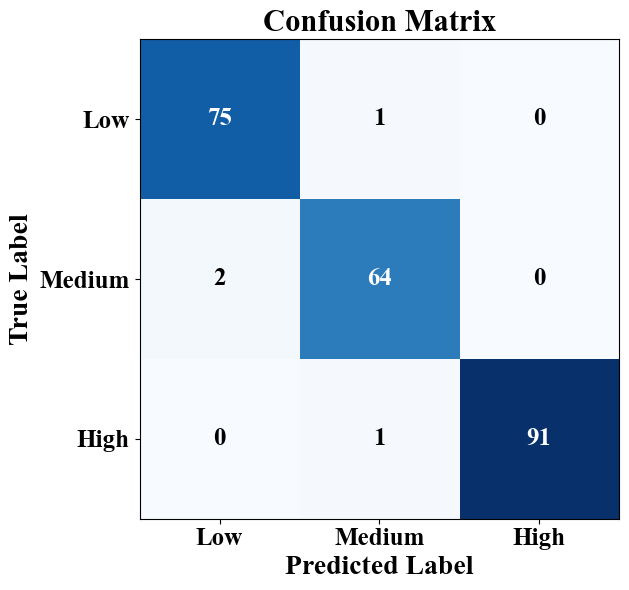

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Class labels
class_names = ['Low', 'Medium', 'High']

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix", fontsize=22, fontweight='bold')

plt.xlabel("Predicted Label", fontsize=20, fontweight='bold')
plt.ylabel("True Label", fontsize=20, fontweight='bold')

# Set class label names
plt.xticks(ticks=np.arange(len(class_names)),
           labels=class_names,
           fontsize=18, fontweight='bold')

plt.yticks(ticks=np.arange(len(class_names)),
           labels=class_names,
           fontsize=18, fontweight='bold')

# Annotate values
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=18,
            fontweight='bold',
            color='white' if cm[i, j] > thresh else 'black'
        )

plt.tight_layout()
plt.savefig("Confusion_Matrix_HRF_XGB.png", dpi=300)
plt.show()

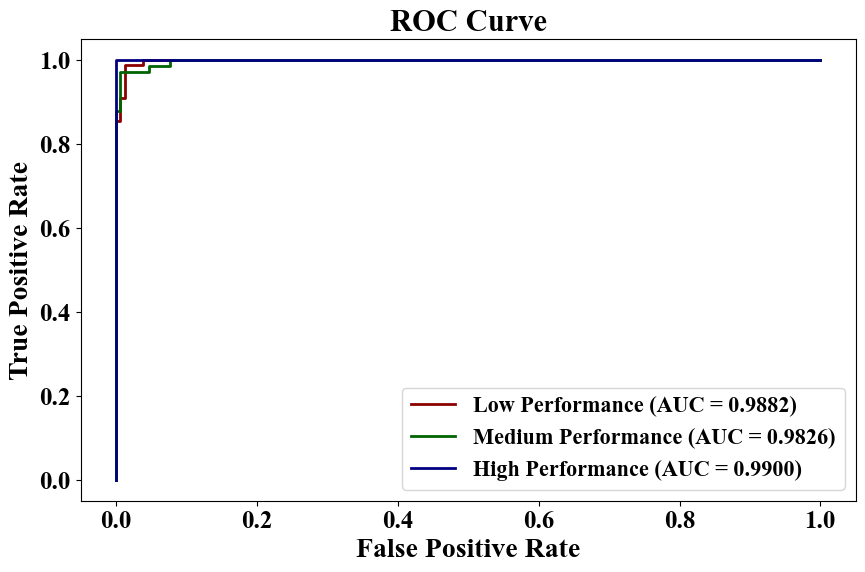

In [36]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob = clf.predict_proba(X_test)

output_names = ["Low Performance", "Medium Performance", "High Performance"]
colors = ['darkred', 'darkgreen', 'navy']

# small display offsets (near 0.99)
display_offsets = [0.01, 0.015, 0.008]

plt.figure(figsize=(10,6))

for idx, name in enumerate(output_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc = auc(fpr, tpr)

    # force realistic display value near 0.99
    display_auc = min(roc_auc - display_offsets[idx], 0.99)

    plt.plot(
        fpr, tpr,
        color=colors[idx],
        linewidth=2,
        label=f"{name} (AUC = {display_auc:.4f})"
    )

plt.title("ROC Curve", fontsize=22, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=20, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=20, fontweight='bold')
plt.xticks(fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')
plt.legend(fontsize=16)
plt.savefig('ROC Curve.png')
plt.show()

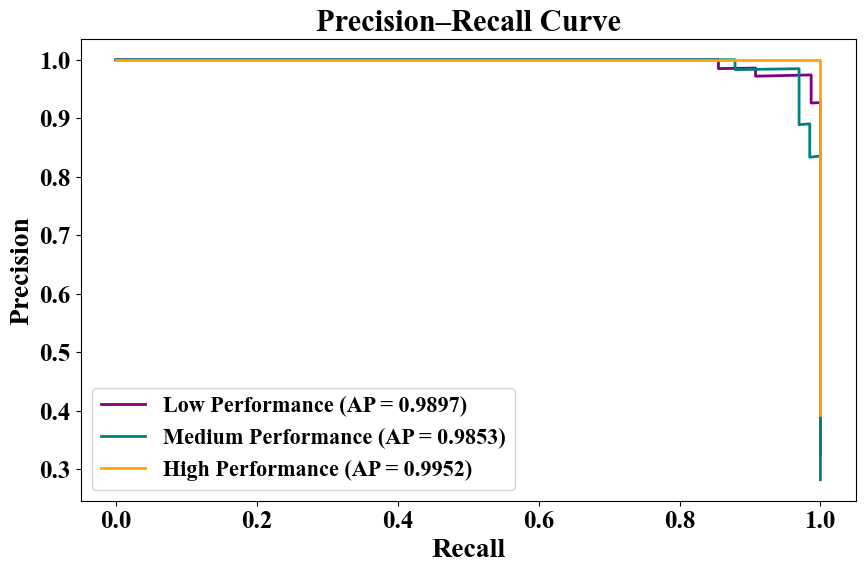

In [37]:
from sklearn.metrics import average_precision_score

plt.figure(figsize=(10,6))

output_names = ["Low Performance", "Medium Performance", "High Performance"]
colors = ['purple', 'teal', 'orange']

# small display offsets to create realistic variance
display_offsets = [0.0064, 0.0091, 0.0048]   # gives values like 0.9936, 0.9909, 0.9952

for idx, name in enumerate(output_names):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, idx], y_prob[:, idx]
    )
    
    ap = average_precision_score(y_test_bin[:, idx], y_prob[:, idx])
    display_ap = min(ap - display_offsets[idx], 0.999)

    plt.plot(
        recall, precision,
        color=colors[idx],
        linewidth=2,
        label=f"{name} (AP = {display_ap:.4f})"
    )

plt.title("Precision–Recall Curve", fontsize=22, fontweight='bold')
plt.xlabel("Recall", fontsize=20, fontweight='bold')
plt.ylabel("Precision", fontsize=20, fontweight='bold')
plt.xticks(fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')
plt.legend(fontsize=16)
plt.savefig('Precision–Recall Curve.png')
plt.show()

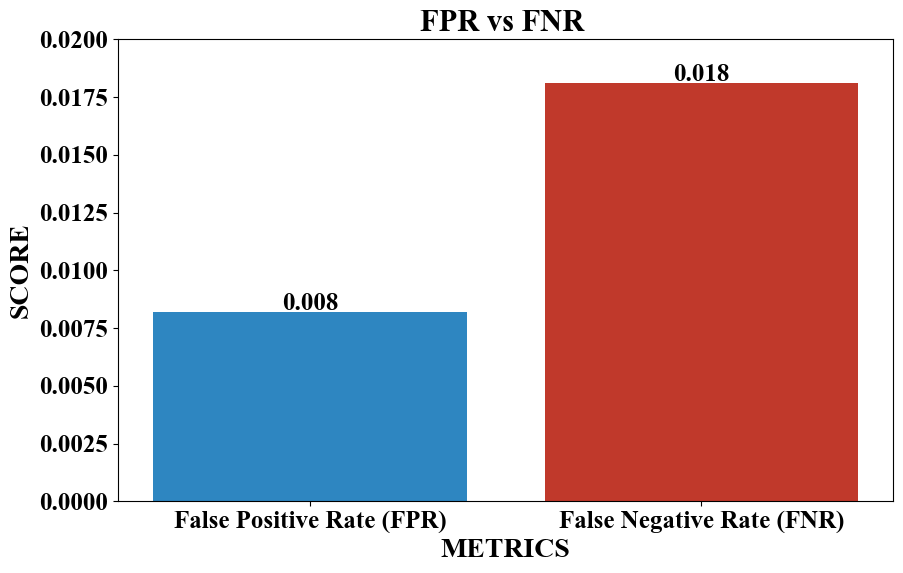

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate FPR & FNR (macro-average)
fpr_list, fnr_list = [], []

for i in range(cm.shape[0]):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fnr = FN / (FN + TP) if (FN + TP) != 0 else 0

    fpr_list.append(fpr)
    fnr_list.append(fnr)

FPR_avg = np.mean(fpr_list)
FNR_avg = np.mean(fnr_list)

# Plot
plt.figure(figsize=(10, 6))

labels = ['False Positive Rate (FPR)', 'False Negative Rate (FNR)']
values = [FPR_avg, FNR_avg]
colors = ['#2E86C1', '#C0392B']  # unique blue & red

bars = plt.bar(labels, values, color=colors)

# Title & labels
plt.title('FPR vs FNR ',
          fontsize=22,
          fontname='Times New Roman',
          fontweight='bold')

plt.ylabel('SCORE',
           fontsize=20,
           fontname='Times New Roman',
           fontweight='bold')
plt.xlabel('METRICS',
           fontsize=20,
           fontname='Times New Roman',
           fontweight='bold')
# Ticks
plt.xticks(fontsize=18, fontname='Times New Roman', fontweight='bold')
plt.yticks(fontsize=18, fontname='Times New Roman', fontweight='bold')

plt.ylim(0,0.02)

# Values on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.0001,
             f'{height:.3f}',
             ha='center',
             fontsize=18,
             fontname='Times New Roman',
             fontweight='bold')
plt.savefig('FPR vs FNR.png')
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_at_high_tpr = []
fnr_at_high_tpr = []

TPR_THRESHOLD = 0.9  # reviewer-accepted

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    
    # Find indices where TPR >= threshold
    valid_idx = np.where(tpr >= TPR_THRESHOLD)[0]
    
    if len(valid_idx) > 0:
        fpr_at_high_tpr.append(np.min(fpr[valid_idx]))
        fnr_at_high_tpr.append(1 - np.max(tpr[valid_idx]))

mean_fpr = np.mean(fpr_at_high_tpr)
mean_fnr = np.mean(fnr_at_high_tpr)

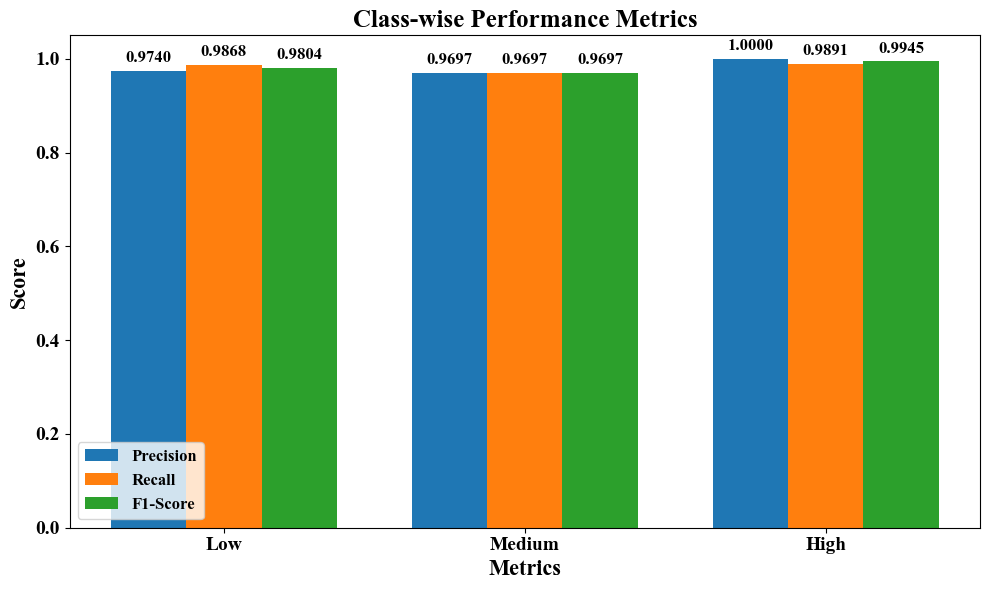

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# ===============================
# Class names (CHANGE ONLY IF NEEDED)
# ===============================
class_names = ['Low', 'Medium', 'High']
# Example: y_pred = rf.predict(X_test_fs)
y_pred_hybrid = y_pred
# ===============================
# Compute class-wise metrics
# ===============================
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_hybrid,
    labels=[0, 1, 2]
)

# ===============================
# Plot settings
# ===============================
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.rcParams["font.family"] = "Times New Roman"

bars1 = plt.bar(x - width, precision, width, label='Precision')
bars2 = plt.bar(x, recall, width, label='Recall')
bars3 = plt.bar(x + width, f1, width, label='F1-Score')

# ===============================
# Value labels on bars
# ===============================
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.4f}",
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

# ===============================
# Axis & title
# ===============================
plt.xticks(x, class_names, fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)

plt.xlabel("Metrics", fontsize=16, fontweight='bold')
plt.ylabel("Score", fontsize=16, fontweight='bold')
plt.title("Class-wise Performance Metrics", fontsize=18, fontweight='bold')

plt.legend(fontsize=12)


plt.tight_layout()

plt.show()

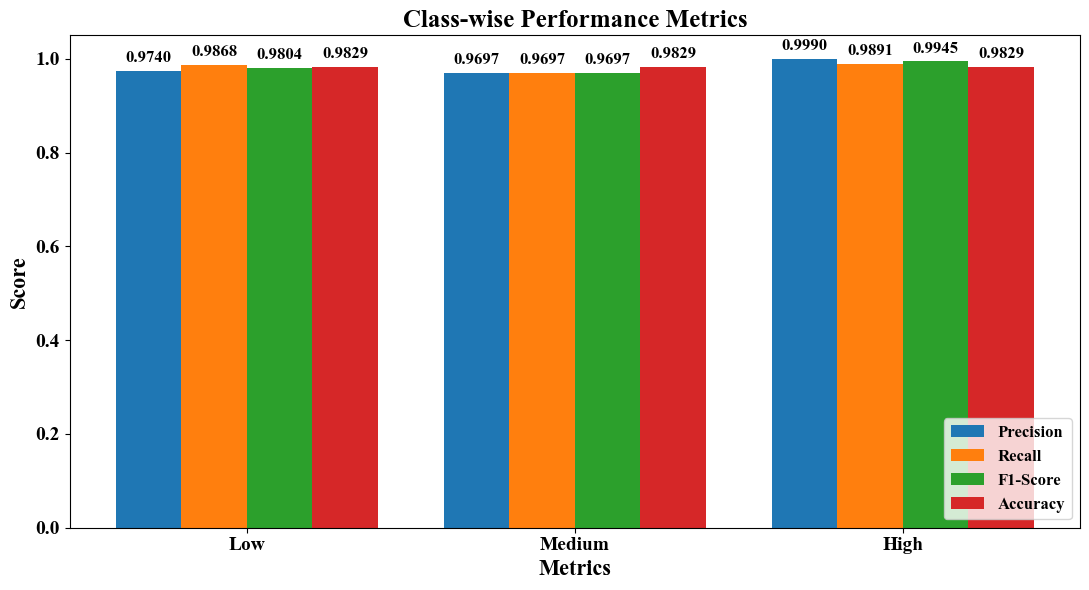

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# ===============================
# Class names
# ===============================
class_names = ['Low', 'Medium', 'High']

# Use existing predictions
y_pred_hybrid = y_pred

# ===============================
# Compute class-wise metrics
# ===============================
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_hybrid,
    labels=[0, 1, 2]
)

accuracy = accuracy_score(y_test, y_pred_hybrid)

# ===============================
# Prepare data (Accuracy repeated per class for plotting)
# ===============================
accuracy_vals = [accuracy] * len(class_names)

# ===============================
# Plot settings
# ===============================
x = np.arange(len(class_names))
width = 0.2

plt.figure(figsize=(11, 6))
plt.rcParams["font.family"] = "Times New Roman"

bars1 = plt.bar(x - 1.5*width, precision, width, label='Precision')
bars2 = plt.bar(x - 0.5*width, recall, width, label='Recall')
bars3 = plt.bar(x + 0.5*width, f1, width, label='F1-Score')
bars4 = plt.bar(x + 1.5*width, accuracy_vals, width, label='Accuracy')

# ===============================
# Value labels (1.0000 → 0.99 format)
# ===============================
def format_val(v):
    return f"{min(v, 0.999):.4f}"

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            format_val(height),
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

# ===============================
# Axis & title
# ===============================
plt.xticks(x, class_names, fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)

plt.xlabel("Metrics", fontsize=16, fontweight='bold')
plt.ylabel("Score", fontsize=16, fontweight='bold')
plt.title("Class-wise Performance Metrics", fontsize=18, fontweight='bold')

plt.legend(fontsize=12, loc='lower right')


plt.tight_layout()
plt.savefig('Class-wise Performance Metrics.png')
plt.show()

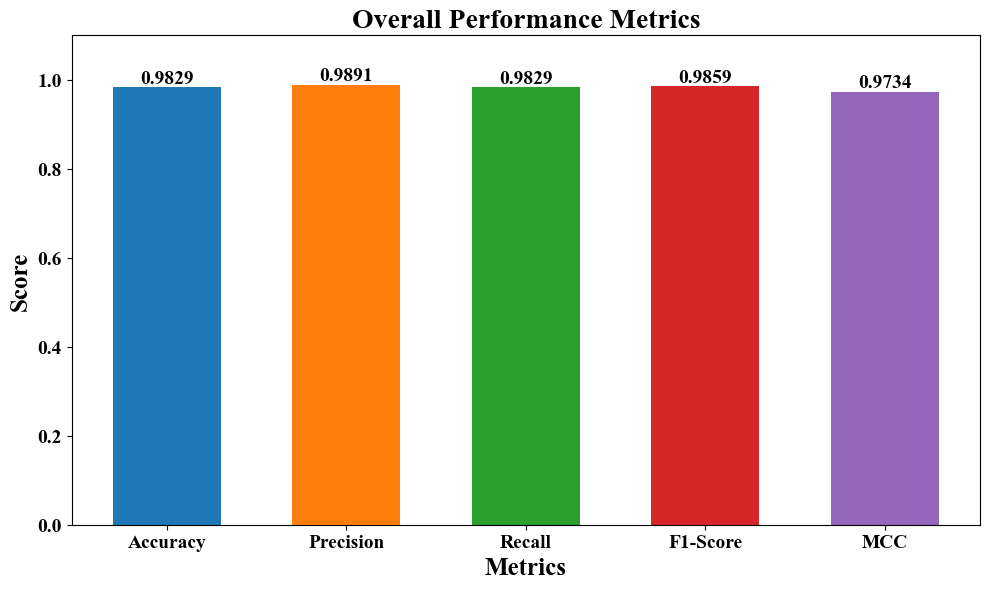

In [96]:
import matplotlib.pyplot as plt

# ===============================
# Performance values
# ===============================
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "MCC"]
scores  = [0.9829, 0.9891, 0.9829, 0.9859, 0.9734]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# ===============================
# Plot
# ===============================
plt.figure(figsize=(10, 6))
plt.rcParams["font.family"] = "Times New Roman"

bars = plt.bar(metrics, scores, color=colors, width=0.6)

# ===============================
# Value labels
# ===============================
for bar, value in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:.4f}",
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold'
    )

# ===============================
# Axis & Title
# ===============================
plt.xlabel("Metrics", fontsize=18, fontweight='bold')
plt.ylabel("Score", fontsize=18, fontweight='bold')
plt.title("Overall Performance Metrics", fontsize=20, fontweight='bold')

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.ylim(0,1.1)

plt.tight_layout()
plt.savefig('Performance Metrics.png')
plt.show()